<a href="https://colab.research.google.com/github/MashaKul/-1/blob/main/findings_gradcam0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
print(sys.executable)
print(sys.version)

/home/m.kuleshova/anaconda3/envs/py312/bin/python
3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:16:04) [GCC 11.2.0]


In [ ]:
import sys
import subprocess
#subprocess.check_call([sys.executable, "-m", "pip", "install", "albumentations", "imageio", "opencv-python"])

In [ ]:
import torch

print(f"Доступно GPU: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    device = 6
    print(f"Используется GPU: {device} - {torch.cuda.get_device_name(device)}")
else:
    device = -1
    print("Используется CPU")

Доступно GPU: 7
Используется GPU: 6 - NVIDIA GeForce RTX 2080 Ti


In [ ]:
import itertools  # Итераторы и комбинаторика (переборы, комбинации, permutations)
import json  # Работа с JSON-форматом (чтение/запись)
import pathlib  # Работа с путями файловой системы (объектно-ориентированный подход)
import pickle  # Сериализация объектов Python (сохранение/загрузка)

import albumentations  # Аугментация изображений (трансформации, увеличение данных)
import imageio  # Чтение/запись изображений и видео различных форматов
import imageio.v2  # Специфическая версия imageio (обратная совместимость)
import matplotlib.pyplot as plt  # Построение графиков и визуализация данных
import numpy as np  # Научные вычисления, работа с многомерными массивами
import pandas as pd  # Анализ и обработка табличных данных (DataFrame)
import PIL.Image  # Работа с изображениями (открытие, обработка, сохранение)
import scipy.stats  # Статистические функции и распределения
import seaborn as sns  # Статистическая визуализация на основе matplotlib
import skimage.exposure  # Обработка гистограмм и яркости изображений
import skimage.transform  # Трансформации изображений (масштабирование, поворот)
import sklearn.ensemble  # Ансамблевые методы машинного обучения (Random Forest и т.д.)
import sklearn.linear_model  # Линейные модели (логистическая регрессия и др.)
import sklearn.metrics  # Метрики оценки моделей (accuracy, precision, recall)
import sklearn.model_selection  # Разделение данных, кросс-валидация
import sklearn.pipeline  # Создание конвейеров обработки данных
import sklearn.preprocessing  # Предобработка данных (нормализация, кодирование)
import transformers  # Библиотека трансформеров (BERT, GPT и другие NLP модели)
import tqdm.auto  # Индикаторы прогресса для циклов (автоматический выбор стиля)

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModel
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
import tqdm.auto
import pickle
import os

# Загрузить модель

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
import transformers

#embedder = transformers.pipeline(task='image-feature-extraction', model='microsoft/rad-dino-maira-2', pool=True, batch_size=32, device=device)

# Загрузить разметку

In [ ]:
import xml.etree
import xml.etree.ElementTree

In [ ]:
XML_PATH = '/home/y.pchelintsev/fast_storage/datasets/chest-x-ray/tb-detection/annotations-after-reannotation.xml' # переразмечнные - не нужны
REANNOTATED_DIR = 'for_nmic_reannotation'

In [ ]:
all_tree = tree = xml.etree.ElementTree.parse(XML_PATH)
print(all_tree)

In [ ]:
tree = xml.etree.ElementTree.parse(XML_PATH).getroot()
tree

<Element 'annotations' at 0x7f72418e0950>

In [ ]:
tasks_tree = tree.find('meta').find('project').find('tasks')
tasks_tree

<Element 'tasks' at 0x7f72418e0cc0>

In [ ]:
labels = [x.find('name').text for x in tree.find('meta').find('project').find('labels').findall('label')]
print(labels)

['Затенение (плевральный выпот)', 'Затенение (в легком)', 'Очаги в легких', 'Очаговая диссеминация', 'Просветление (кольцевидная тень в легком)', 'Просветление (газ плевральной полости, в том числе пневмоторакс)', 'Кальцинированные очаги (петрификаты)', 'Прочая ненорма']


In [ ]:
images = [
    {
        'file_path': x.attrib['name'],
        'task_id': x.attrib['task_id'],
        'width': x.attrib['width'],
        'height': x.attrib['height'],
        'findings': [{'label': y.attrib['label'], 'points': y.attrib['points']} for y in x.findall('polygon')]
    }
    for x in tree.findall('image')
    if not any(x.startswith('.') for x in pathlib.Path(x.attrib['name']).expanduser().resolve().parts)
]

k = 0
for img in images:
    if k >= 10:
        break
    k += 1
    print(f"Image: {img['file_path']}")
    print(f"Findings count: {len(img['findings'])}")
    for finding in img['findings']:
        print(f"  - Label: {finding['label']}, Points: {finding['points']}")
    print()

Image: Sakha-TB-8bit/images/TB/tb400.png
Findings count: 1
  - Label: Очаги в легких, Points: 351.35,141.63;393.85,149.21;412.06,168.94;424.20,196.26;409.02,237.23;357.42,235.72;324.04,228.13;321.00,191.71;333.14,149.21

Image: Sakha-TB-8bit/images/TB/tb401.png
Findings count: 8
  - Label: Очаговая диссеминация, Points: 761.96,561.22;817.18,423.91;770.92,282.13;735.10,220.93;660.47,226.90;657.49,392.57;690.32,507.49
  - Label: Просветление (кольцевидная тень в легком), Points: 720.17,277.65;735.10,241.83;717.19,214.96;685.84,201.53;664.95,207.50;685.84,238.84
  - Label: Затенение (в легком), Points: 676.11,566.54;726.19,575.65;761.09,607.52;796.00,645.46;818.76,715.26;771.72,710.71;712.53,692.50;654.86,674.29;647.28,609.03
  - Label: Очаговая диссеминация, Points: 392.33,77.89;443.92,76.37;483.38,106.72;504.63,165.91;519.80,220.54;510.70,279.72;489.45,320.70;443.92,388.99;378.67,378.37;314.93,364.71;273.96,358.64;258.78,291.87;286.10,194.74;305.83,135.56;345.28,96.10
  - Label: Кальцин

In [ ]:
needed_labels = labels[:-1]
print(needed_labels)
print(len(needed_labels))

['Затенение (плевральный выпот)', 'Затенение (в легком)', 'Очаги в легких', 'Очаговая диссеминация', 'Просветление (кольцевидная тень в легком)', 'Просветление (газ плевральной полости, в том числе пневмоторакс)', 'Кальцинированные очаги (петрификаты)']
7


In [ ]:
'''
images = [
    {
        'file_path': x.attrib['name'],
        'task_id': x.attrib['task_id'],
        'width': x.attrib['width'],
        'height': x.attrib['height'],
        'findings': [{'label': y.attrib['label'], 'points': y.attrib['points']} for y in x.findall('polygon')]
    }
    for x in tree.findall('image')
    if not any(x.startswith('.') for x in pathlib.Path(x.attrib['name']).expanduser().resolve().parts)
]

labels = ['Затенение (плевральный выпот)', 'Затенение (в легком)', 'Очаги в легких', 'Очаговая диссеминация', 'Просветление (кольцевидная тень в легком)', 'Просветление (газ плевральной полости, в том числе пневмоторакс)', 'Кальцинированные очаги (петрификаты)', 'Прочая ненорма']
'''

for img in images:
    for lbl in labels:
        img[lbl] = int(lbl in [x['label'] for x in img['findings']])
        #print(img[lbl])

df = pd.DataFrame(images)
df

,file_path,task_id,width,height,findings,Затенение (плевральный выпот),Затенение (в легком),Очаги в легких,Очаговая диссеминация,Просветление (кольцевидная тень в легком),"Просветление (газ плевральной полости, в том числе пневмоторакс)",Кальцинированные очаги (петрификаты),Прочая ненорма
0,Sakha-TB-8bit/images/TB/tb400.png,2,994,994,"[{'label': 'Очаги в легких', 'points': '351.35...",0,0,1,0,0,0,0,0
1,Sakha-TB-8bit/images/TB/tb401.png,2,994,994,"[{'label': 'Очаговая диссеминация', 'points': ...",0,1,1,1,1,0,1,1
2,Sakha-TB-8bit/images/TB/tb402.png,2,994,994,"[{'label': 'Очаги в легких', 'points': '378.82...",0,0,1,0,0,0,0,0
3,Sakha-TB-8bit/images/TB/tb403.png,2,994,994,"[{'label': 'Очаги в легких', 'points': '446.96...",0,0,1,0,0,0,0,0
4,Sakha-TB-8bit/images/TB/tb404.png,2,994,994,"[{'label': 'Очаги в легких', 'points': '161.66...",0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3201,CXR/for_nmic_reannotation/CXR/2024.12.03/Data ...,32,1198,989,"[{'label': 'Прочая ненорма', 'points': '192.20...",0,0,0,0,0,0,0,1
3202,CXR/for_nmic_reannotation/Sakha-TB-8bit/images...,32,994,994,[{'label': 'Кальцинированные очаги (петрификат...,0,0,0,0,0,0,1,0
3203,CXR/for_nmic_reannotation/CXR/2025.03.19/выпот...,32,2840,2853,"[{'label': 'Затенение (плевральный выпот)', 'p...",1,0,0,0,0,0,0,1
3204,CXR/for_nmic_reannotation/CXR/2025.06.03/png/0...,32,2840,2853,[],0,0,0,0,0,0,0,0


In [ ]:
df['relative_file_path'] = df['file_path'].apply(lambda x: x.split(f'{REANNOTATED_DIR}/')[-1])
df

,file_path,task_id,width,height,findings,Затенение (плевральный выпот),Затенение (в легком),Очаги в легких,Очаговая диссеминация,Просветление (кольцевидная тень в легком),"Просветление (газ плевральной полости, в том числе пневмоторакс)",Кальцинированные очаги (петрификаты),Прочая ненорма,relative_file_path
0,Sakha-TB-8bit/images/TB/tb400.png,2,994,994,"[{'label': 'Очаги в легких', 'points': '351.35...",0,0,1,0,0,0,0,0,Sakha-TB-8bit/images/TB/tb400.png
1,Sakha-TB-8bit/images/TB/tb401.png,2,994,994,"[{'label': 'Очаговая диссеминация', 'points': ...",0,1,1,1,1,0,1,1,Sakha-TB-8bit/images/TB/tb401.png
2,Sakha-TB-8bit/images/TB/tb402.png,2,994,994,"[{'label': 'Очаги в легких', 'points': '378.82...",0,0,1,0,0,0,0,0,Sakha-TB-8bit/images/TB/tb402.png
3,Sakha-TB-8bit/images/TB/tb403.png,2,994,994,"[{'label': 'Очаги в легких', 'points': '446.96...",0,0,1,0,0,0,0,0,Sakha-TB-8bit/images/TB/tb403.png
4,Sakha-TB-8bit/images/TB/tb404.png,2,994,994,"[{'label': 'Очаги в легких', 'points': '161.66...",0,0,1,0,0,0,0,0,Sakha-TB-8bit/images/TB/tb404.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3201,CXR/for_nmic_reannotation/CXR/2024.12.03/Data ...,32,1198,989,"[{'label': 'Прочая ненорма', 'points': '192.20...",0,0,0,0,0,0,0,1,CXR/2024.12.03/Data Set_Забайкалье 101/102.png
3202,CXR/for_nmic_reannotation/Sakha-TB-8bit/images...,32,994,994,[{'label': 'Кальцинированные очаги (петрификат...,0,0,0,0,0,0,1,0,Sakha-TB-8bit/images/TB/tb748.png
3203,CXR/for_nmic_reannotation/CXR/2025.03.19/выпот...,32,2840,2853,"[{'label': 'Затенение (плевральный выпот)', 'p...",1,0,0,0,0,0,0,1,CXR/2025.03.19/выпот в плевральную полость 173...
3204,CXR/for_nmic_reannotation/CXR/2025.06.03/png/0...,32,2840,2853,[],0,0,0,0,0,0,0,0,CXR/2025.06.03/png/0306нмиц_обезл/5. Кальцинат...


In [ ]:
same_path = df.duplicated(subset=['relative_file_path'], keep=False)
reannotated = df['file_path'].str.contains(REANNOTATED_DIR)
non_empty = df[labels].apply(max, axis=1) > 0

In [ ]:
print('Переразмечено с новой разметкой:', reannotated.sum())
print('Переразмечено с новой и старой разметкой:', same_path.sum())
print('Перерамечено с новой разметкой и можно использовать:', (reannotated & non_empty).sum())
print('Переразмечено со старой разметкой и можно использовать:', (same_path & ~reannotated & non_empty).sum())

Переразмечено с новой разметкой: 436
Переразмечено с новой и старой разметкой: 872
Перерамечено с новой разметкой и можно использовать: 426
Переразмечено со старой разметкой и можно использовать: 436


In [ ]:
# Дубликатов по пути среди "староразмеченных" снимков нет
df[~reannotated].duplicated(subset=['relative_file_path'], keep=False).any()

np.False_

In [ ]:
# Дубликатов по пути среди "новоразмеченных" снимков нет
df[reannotated].duplicated(subset=['relative_file_path'], keep=False).any()

np.False_

In [ ]:
# Поэтому можно использовать эти маски для разделения старой разметки, новой разметки и нетронутой разметки
df['reannotated'] = reannotated
df['not_reannotated'] = ~same_path
df['reannotated_old_annotations'] = ~reannotated & same_path

In [ ]:
# Заменить староразмеченные новоразмеченными, и только потом удалить пустые снимки
df_final = df[non_empty].copy()
df_old = df_final
df_final['final_file_path'] = df_final['relative_file_path'].apply(lambda x: str(pathlib.Path('/home/y.pchelintsev/fast_storage/datasets/chest-x-ray/tb-detection') / x))
assert df_final['final_file_path'].apply(lambda x: pathlib.Path(x).exists()).all()
df_final

,file_path,task_id,width,height,findings,Затенение (плевральный выпот),Затенение (в легком),Очаги в легких,Очаговая диссеминация,Просветление (кольцевидная тень в легком),"Просветление (газ плевральной полости, в том числе пневмоторакс)",Кальцинированные очаги (петрификаты),Прочая ненорма,relative_file_path,reannotated,not_reannotated,reannotated_old_annotations,final_file_path
0,Sakha-TB-8bit/images/TB/tb400.png,2,994,994,"[{'label': 'Очаги в легких', 'points': '351.35...",0,0,1,0,0,0,0,0,Sakha-TB-8bit/images/TB/tb400.png,False,True,False,/home/y.pchelintsev/fast_storage/datasets/ches...
1,Sakha-TB-8bit/images/TB/tb401.png,2,994,994,"[{'label': 'Очаговая диссеминация', 'points': ...",0,1,1,1,1,0,1,1,Sakha-TB-8bit/images/TB/tb401.png,False,True,False,/home/y.pchelintsev/fast_storage/datasets/ches...
2,Sakha-TB-8bit/images/TB/tb402.png,2,994,994,"[{'label': 'Очаги в легких', 'points': '378.82...",0,0,1,0,0,0,0,0,Sakha-TB-8bit/images/TB/tb402.png,False,True,False,/home/y.pchelintsev/fast_storage/datasets/ches...
3,Sakha-TB-8bit/images/TB/tb403.png,2,994,994,"[{'label': 'Очаги в легких', 'points': '446.96...",0,0,1,0,0,0,0,0,Sakha-TB-8bit/images/TB/tb403.png,False,True,False,/home/y.pchelintsev/fast_storage/datasets/ches...
4,Sakha-TB-8bit/images/TB/tb404.png,2,994,994,"[{'label': 'Очаги в легких', 'points': '161.66...",0,0,1,0,0,0,0,0,Sakha-TB-8bit/images/TB/tb404.png,False,True,False,/home/y.pchelintsev/fast_storage/datasets/ches...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3200,CXR/for_nmic_reannotation/CXR/2025.03.28/png/D...,32,3072,3008,"[{'label': 'Затенение (плевральный выпот)', 'p...",1,0,0,1,0,0,0,1,CXR/2025.03.28/png/Desktop.rar_pass_3#xWX4gv/С...,True,False,False,/home/y.pchelintsev/fast_storage/datasets/ches...
3201,CXR/for_nmic_reannotation/CXR/2024.12.03/Data ...,32,1198,989,"[{'label': 'Прочая ненорма', 'points': '192.20...",0,0,0,0,0,0,0,1,CXR/2024.12.03/Data Set_Забайкалье 101/102.png,True,False,False,/home/y.pchelintsev/fast_storage/datasets/ches...
3202,CXR/for_nmic_reannotation/Sakha-TB-8bit/images...,32,994,994,[{'label': 'Кальцинированные очаги (петрификат...,0,0,0,0,0,0,1,0,Sakha-TB-8bit/images/TB/tb748.png,True,False,False,/home/y.pchelintsev/fast_storage/datasets/ches...
3203,CXR/for_nmic_reannotation/CXR/2025.03.19/выпот...,32,2840,2853,"[{'label': 'Затенение (плевральный выпот)', 'p...",1,0,0,0,0,0,0,1,CXR/2025.03.19/выпот в плевральную полость 173...,True,False,False,/home/y.pchelintsev/fast_storage/datasets/ches...


In [ ]:
# Новый тестовый набор: переаннотированные данные (улучшенные разметки)
test_set_new = df_final[df_final['reannotated']]
# Старый тестовый набор: оригинальные аннотации до переразметки
test_set_old = df_final[df_final['reannotated_old_annotations']]
# Тренировочный набор: данные без повторной аннотации (базовая разметка)
train_set = df_final[df_final['not_reannotated']]

assert (
    len(set(train_set.index) & set(test_set_old)) == 0
    and len(set(train_set.index) & set(test_set_new)) == 0
    and len(set(test_set_old.index) & set(test_set_new)) == 0
)
len(train_set), len(test_set_new), len(test_set_old)

(1892, 426, 436)

In [ ]:
with open('dataframe.json', 'w', encoding='utf-8') as fp:
    json.dump(df_final.to_dict(orient='records'), fp, ensure_ascii=False, indent=4)

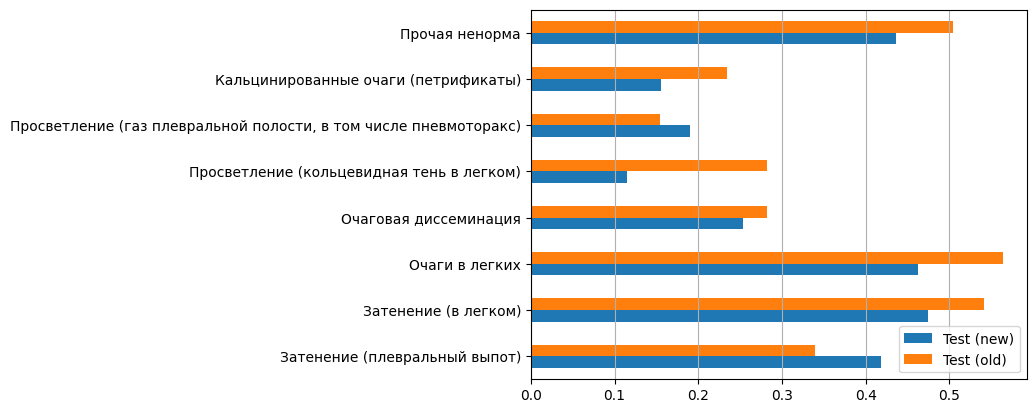

In [ ]:
_ = pd.DataFrame({'Test (new)': test_set_new[labels].mean(), 'Test (old)': test_set_old[labels].mean()}).plot.barh()
plt.grid(axis='x')
# plt.tight_layout()

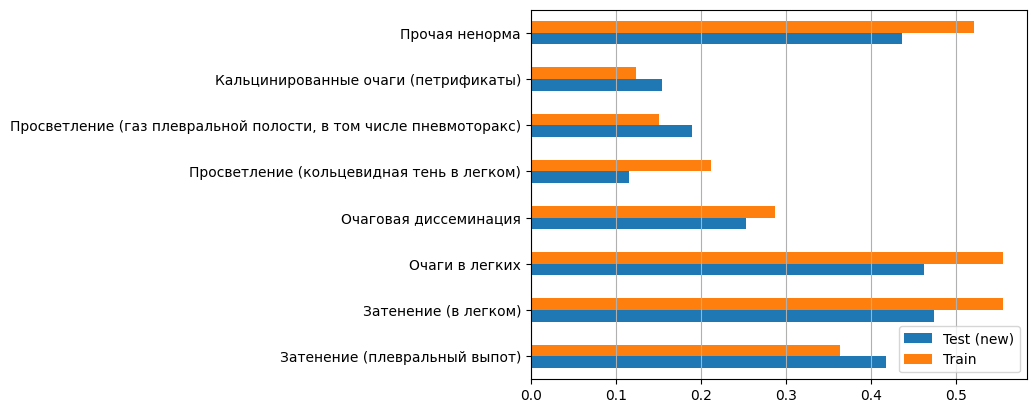

In [ ]:
_ = pd.DataFrame({'Test (new)': test_set_new[labels].mean(), 'Train': train_set[labels].mean()}).plot.barh()
plt.grid(axis='x')
# plt.tight_layout()

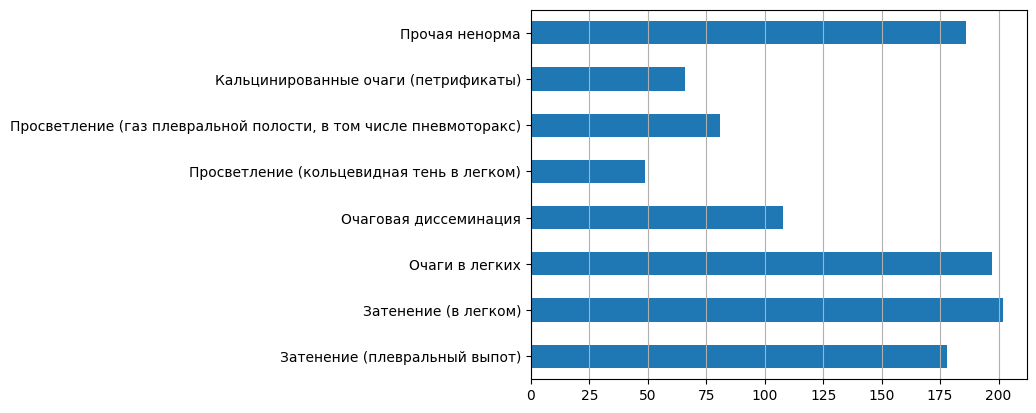

In [ ]:
_ = test_set_new[labels].sum().plot.barh()
plt.grid(axis='x')

<Axes: >

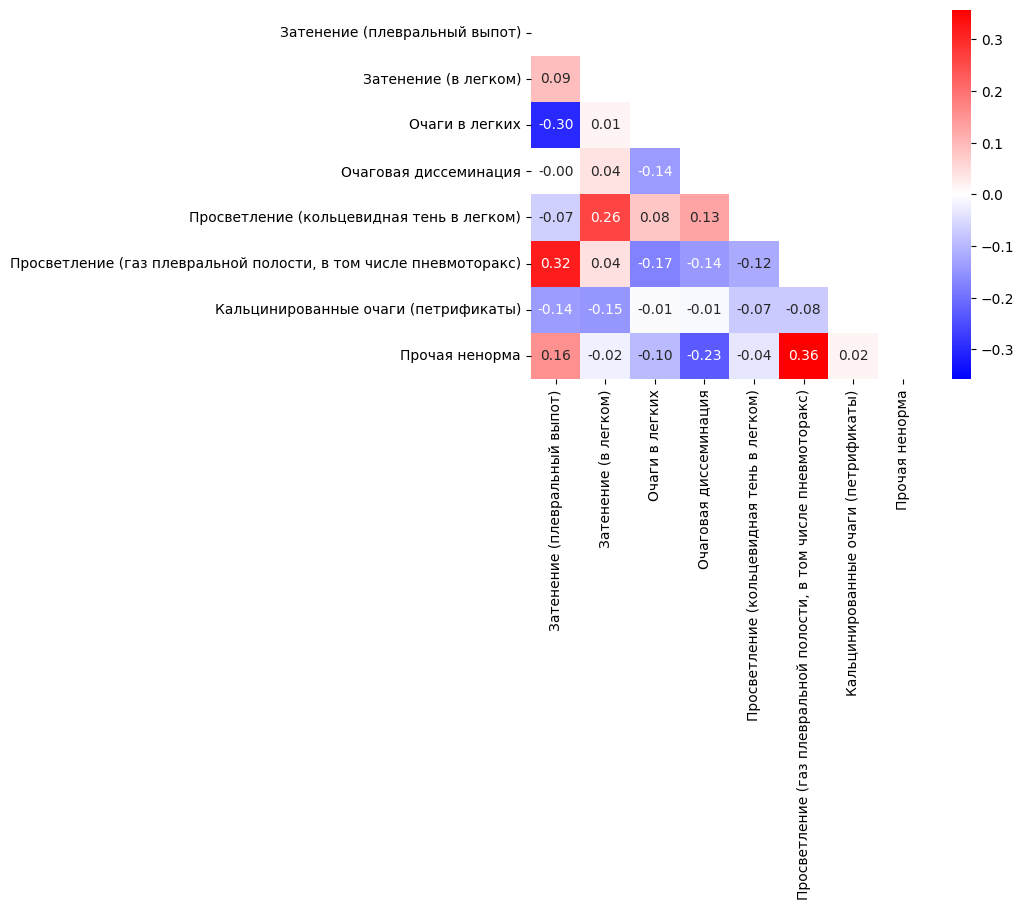

In [ ]:
corr = test_set_new[labels].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
lim = np.abs(np.where(~mask, corr.values, 0)).max()
sns.heatmap(corr, vmin=-1*lim, vmax=1*lim, cmap='bwr', annot=True, fmt='.2f', mask=mask)

<Axes: >

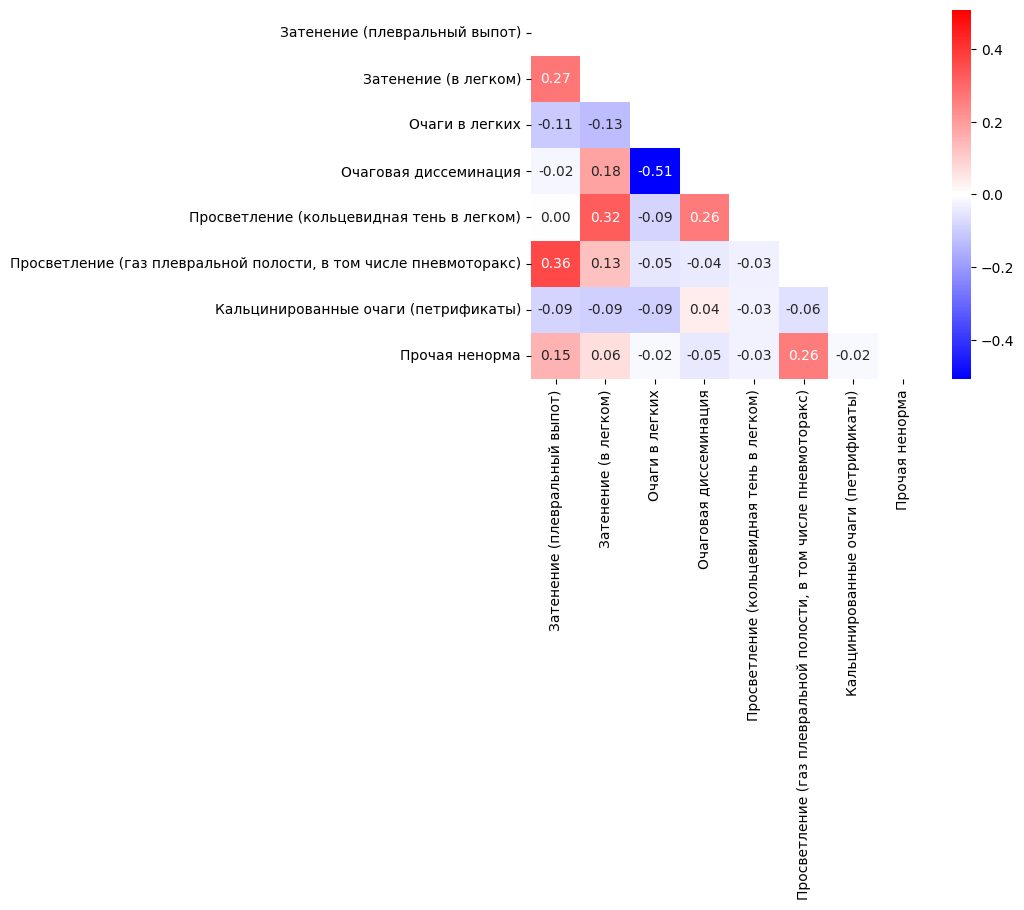

In [ ]:
corr = train_set[labels].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
lim = np.abs(np.where(~mask, corr.values, 0)).max()
sns.heatmap(corr, vmin=-1*lim, vmax=1*lim, cmap='bwr', annot=True, fmt='.2f', mask=mask)

# Получить эмбеддинги

In [ ]:
"""
if not features:
    batch_size = embedder._batch_size
    group_number = 0

    for set_, df_ in [('train', train_set), ('test_new', test_set_new), ('test_old', test_set_old)]:
        features[set_] = {}
        # df_ = df_.sample(frac=0.1)

        indices = list(range(len(df_)))
        for left in tqdm.auto.trange(0, len(indices), batch_size, smoothing=0.0):
            batch = indices[left : min(left + batch_size, len(indices))]
            images = [read_image(img_fname) for img_fname in df_['final_file_path'].iloc[batch]]

            positive_images = [PIL.Image.fromarray((img * 255).astype(np.uint8)) for img in images]
            negative_images = [PIL.Image.fromarray(((1 - img) * 255).astype(np.uint8)) for img in images]

            for ix, embeddings_p, embeddings_n in zip(batch, embedder(positive_images), embedder(negative_images)):
                features[set_].setdefault('features', []).append(embeddings_p[0])
                features[set_].setdefault('features', []).append(embeddings_n[0])

                for lbl in labels:
                    features[set_].setdefault(lbl, []).append(df_[lbl].iloc[ix])
                    features[set_].setdefault(lbl, []).append(df_[lbl].iloc[ix])

                features[set_].setdefault('groups', []).append(group_number)
                features[set_].setdefault('groups', []).append(group_number)
                group_number += 1
        #     break
        # break
"""

"\nif not features:\n    batch_size = embedder._batch_size\n    group_number = 0\n\n    for set_, df_ in [('train', train_set), ('test_new', test_set_new), ('test_old', test_set_old)]:\n        features[set_] = {}\n        # df_ = df_.sample(frac=0.1)\n\n        indices = list(range(len(df_)))\n        for left in tqdm.auto.trange(0, len(indices), batch_size, smoothing=0.0):\n            batch = indices[left : min(left + batch_size, len(indices))]\n            images = [read_image(img_fname) for img_fname in df_['final_file_path'].iloc[batch]]\n\n            positive_images = [PIL.Image.fromarray((img * 255).astype(np.uint8)) for img in images]\n            negative_images = [PIL.Image.fromarray(((1 - img) * 255).astype(np.uint8)) for img in images]\n\n            for ix, embeddings_p, embeddings_n in zip(batch, embedder(positive_images), embedder(negative_images)):\n                features[set_].setdefault('features', []).append(embeddings_p[0])\n                features[set_].setdef

1. Нужны ли градиенты для обучения? Или можно заранее высчитать эмбеддинги (выходы кодировщика) для ускорения обучения?
2. Написать класс модель, чтобы можно было подавать bacbone=None.
3. Написать в функции простой цикл обучения.
4. Заменить grad_search на мою модель.

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import numpy as np
import imageio

class Embedder(nn.Module):
    def __init__(self, model_name='microsoft/rad-dino-maira-2', device='cuda'):
        super().__init__()
        self.device = torch.device(device)
        self.processor = AutoImageProcessor.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)

    def forward(self, images, gradcam=False):
        inputs = self.processor(images=images, return_tensors="pt")
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        if gradcam:
            self.model.train()
            outputs = self.model(**inputs)
        else:
            self.model.eval()
            with torch.no_grad():
                outputs = self.model(**inputs)

        return outputs.pooler_output

    def extract_embeddings(self, dataset, labels):
        features = {}
        self.model.eval()

        for set_name, df in dataset:
            features[set_name] = {'features': []}
            for lbl in labels:
                features[set_name][lbl] = []

            for i in range(len(df)):
                image_path = df['final_file_path'].iloc[i]
                img = self._read_image(image_path)
                positive_image = Image.fromarray((img * 255).astype(np.uint8))
                negative_image = Image.fromarray(((1 - img) * 255).astype(np.uint8))

                with torch.no_grad():
                    emb_positive = self(positive_image)
                    emb_negative = self(negative_image)

                features[set_name]['features'].extend([
                    emb_positive.cpu().numpy()[0],
                    emb_negative.cpu().numpy()[0]
                ])

                for lbl in labels:
                    label_val = df[lbl].iloc[i]
                    features[set_name][lbl].extend([label_val, label_val])

        return features

    def _read_image(self, file_path):
        img = imageio.v2.imread(file_path)
        if len(img.shape) == 3:
            img = img[:, :, 0]
        img = img / 255.0
        return img

In [ ]:
class Head(nn.Module):
    def __init__(self, input_size, hidden_size=512, layer_n=3, n_classes=1):
        super().__init__()

        layers = []
        current_size = input_size

        for i in range(layer_n):
            layers.extend([
                nn.Linear(current_size, hidden_size),
                nn.LayerNorm(hidden_size) if i > 0 else nn.Identity(),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            current_size = hidden_size

        layers.append(nn.Linear(hidden_size, n_classes))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        return self.classifier(x).squeeze(-1)

In [ ]:
class MyModel(nn.Module):
    def __init__(self, embedder, head):
        super().__init__()
        self.embedder = embedder
        self.head = head

    def forward(self, x, gradcam=False):
        if gradcam:
            features = self.embedder(x, gradcam=True)
        else:
            features = self.embedder(x)
        return self.head(features)

In [ ]:
#torchvision.models.vit_b_16()

# Прогнать обучение и тесты

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

class ModelTrainer:
    def __init__(self, device='cuda'):
        self.device = torch.device(device)
        self.models = {}

    def train_models(self, features, needed_labels):
        for pathology in needed_labels:
            embeddings = torch.FloatTensor(features['train']['features']).to(self.device)
            labels = torch.FloatTensor(features['train'][pathology]).to(self.device)

            input_size = embeddings.shape[1]
            best_score = 0
            best_model = None

            for lr in [0.001, 0.01]:
                for hidden_size in [512, 1024]:
                    for layer_n in [2, 3]:
                        fold_scores = []

                        kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

                        for fold, (train_idx, val_idx) in enumerate(kfold.split(embeddings.cpu().numpy(), labels.cpu().numpy())):
                            head = Head(input_size, hidden_size, layer_n).to(self.device)
                            model = MyModel(None, head)

                            fold_score = self._train_fold(model, embeddings, labels, train_idx, val_idx, lr)
                            fold_scores.append(fold_score)

                            del model
                            torch.cuda.empty_cache()

                        mean_auc = np.mean(fold_scores)

                        if mean_auc > best_score:
                            best_score = mean_auc
                            best_head = Head(input_size, hidden_size, layer_n).to(self.device)
                            best_model = MyModel(None, best_head)
                            best_model = self._train_full(best_model, embeddings, labels, lr)

            if best_model:
                torch.save(best_model.head.state_dict(), f'{pathology}.pth')
                self.models[pathology] = best_model
                print(f"Модель для {pathology} ---> AUC: {best_score:.4f}")

        return self.models

    def _train_fold(self, model, embeddings, labels, train_idx, val_idx, lr):
        optimizer = torch.optim.AdamW(model.head.parameters(), lr=lr)
        criterion = nn.BCEWithLogitsLoss()

        train_emb = embeddings[train_idx]
        train_lbl = labels[train_idx]
        val_emb = embeddings[val_idx]
        val_lbl = labels[val_idx]

        model.head.train()
        for epoch in range(20):
            for i in range(0, len(train_idx), 128):
                batch_emb = train_emb[i:i+128]
                batch_lbl = train_lbl[i:i+128]

                outputs = model.head(batch_emb)
                loss = criterion(outputs, batch_lbl)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        model.head.eval()
        with torch.no_grad():
            outputs = model.head(val_emb)
            preds = torch.sigmoid(outputs).cpu().numpy()
            auc = roc_auc_score(val_lbl.cpu().numpy(), preds)

        return auc

    def _train_full(self, model, embeddings, labels, lr):
        optimizer = torch.optim.AdamW(model.head.parameters(), lr=lr)
        criterion = nn.BCEWithLogitsLoss()

        model.head.train()
        for epoch in range(20):
            for i in range(0, len(embeddings), 128):
                batch_emb = embeddings[i:i+128]
                batch_lbl = labels[i:i+128]

                outputs = model.head(batch_emb)
                loss = criterion(outputs, batch_lbl)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        return model

In [ ]:
class ImageDatasetManager:
    def __init__(self, embedder):
        self.embedder = embedder
        self.image_dict = {}

    def create_image_dict(self, datasets, needed_labels):
        for set_name, df in datasets:
            self.image_dict[set_name] = {
                'images': []
            }

            for lbl in needed_labels:
                self.image_dict[set_name][lbl] = []

            for i in range(len(df)):
                image_path = df['final_file_path'].iloc[i]

                img = self.embedder._read_image(image_path)
                pos_image = Image.fromarray((img * 255).astype(np.uint8))
                neg_image = Image.fromarray(((1 - img) * 255).astype(np.uint8))

                self.image_dict[set_name]['images'].append(pos_image)
                self.image_dict[set_name]['images'].append(neg_image)

                for lbl in needed_labels:
                    label_value = df[lbl].iloc[i]
                    self.image_dict[set_name][lbl].append(label_value)
                    self.image_dict[set_name][lbl].append(label_value)

        return self.image_dict

    def save_dict(self, file_path):
        with open(file_path, 'wb') as f:
            pickle.dump(self.image_dict, f)
        print(f"Словарь сохранен в {file_path}")

    def load_dict(self, file_path):
        with open(file_path, 'rb') as f:
            self.image_dict = pickle.load(f)
        print(f"Словарь загружен из {file_path}")
        return self.image_dict

In [ ]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

class GradCAMGenerator:
    def __init__(self, device='cuda'):
        self.device = device

    def load_model(self, pathology, embedder):
        head_state_dict = torch.load(f'{pathology}.pth', map_location=self.device)
        head = Head(embedder.model.config.hidden_size, 1024, 3) # TODO: передавать в параметрах гиперпараметры конкретной модели, а то постоянно меняю
        head.load_state_dict(head_state_dict)
        return MyModel(embedder, head).to(self.device)

    def reshape_transform(self, tensor):
        B, N, C = tensor.shape
        token_seq = tensor[:, 1:, :]
        spatial_dim = int((N - 1) ** 0.5)

        result = token_seq.reshape(B, spatial_dim, spatial_dim, C)

        # (B, H, W, C) -> (B, C, H, W)
        result = result.transpose(2, 3).transpose(1, 2)
        return result

    def create_gradcam(self, model, image):
        activations = None
        gradients = None

        def forward_hook(module, input, output):
            nonlocal activations
            activations = output

        def backward_hook(module, grad_input, grad_output):
            nonlocal gradients
            gradients = grad_output[0]

        target_layer = model.embedder.model.encoder.layer[-1]
        forward_handle = target_layer.register_forward_hook(forward_hook)
        backward_handle = target_layer.register_full_backward_hook(backward_hook)

        try:
            with torch.enable_grad():
                output = model(image, gradcam=True)
                prob = torch.sigmoid(output).item()
                target_class = 1 if prob > 0.5 else 0

                model.zero_grad()
                loss = output[0] if target_class == 1 else -output[0]
                loss.backward()

                activations_transformed = self.reshape_transform(activations)
                gradients_transformed = self.reshape_transform(gradients)

                if gradients_transformed.mean().abs() < 1e-6:
                    print("Градиенты нулевые или почти нулевые") # TODO: ТО ЕСТЬ НИХРЕНА НЕ СЧИТАЮТСЯ!!!
                    cam = activations_transformed.mean(dim=1)
                else:
                    weights = gradients_transformed.mean(dim=(2, 3), keepdim=True)
                    cam = torch.sum(weights * activations_transformed, dim=1)

                cam = torch.relu(cam)

                cam_numpy = cam[0].cpu().detach().numpy()
                cam_numpy = np.maximum(cam_numpy, 0)
                cam_numpy = (cam_numpy - cam_numpy.min()) / (cam_numpy.max() - cam_numpy.min())

                return cam_numpy, prob, target_class

        finally:
            forward_handle.remove()
            backward_handle.remove()

    def visualize(self, image, gradcam, alpha=0.5):
        if not isinstance(image, Image.Image):
            image = Image.fromarray((image * 255).astype(np.uint8))

        if image.mode != 'L':
            image_gray = image.convert('L')
        else:
            image_gray = image

        img_array = np.array(image_gray)

        if gradcam.shape == img_array.shape:
            heatmap = gradcam
        else:
            heatmap = np.array(Image.fromarray(gradcam).resize(
                image.size, Image.NEAREST
            ))

        if heatmap.max() > heatmap.min():
            heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

        ax1.imshow(img_array, cmap='gray')
        ax1.set_title('Исходник')
        ax1.axis('off')

        ax2.imshow(img_array, cmap='gray')
        ax2.imshow(heatmap, alpha=alpha, cmap='jet')
        ax2.set_title('Grad-CAM наложение')
        ax2.axis('off')

        plt.tight_layout()

        return fig, heatmap

    def generate(self, pathology, image_dict, test_set='test_old'):
        embedder = Embedder(device=self.device)
        model = self.load_model(pathology, embedder)

        images = image_dict[test_set]['images']
        image = random.choice(images)

        gradcam, prob, target_class = self.create_gradcam(model, image)
        fig, overlay = self.visualize(image, gradcam)
        print(f"{pathology}: вероятность = {prob:.3f}, класс = {target_class}")

        return fig, overlay, prob, target_class

In [ ]:
embedder = Embedder(device='cuda')
dataset_manager = ImageDatasetManager(embedder)
trainer = ModelTrainer(device='cuda')
gradcam_generator = GradCAMGenerator(device='cuda')

In [ ]:
datasets = [
    ('train', train_set),
    ('test_new', test_set_new),
    ('test_old', test_set_old)
]

print("Извлечение эмбеддингов...")
features = embedder.extract_embeddings(datasets, needed_labels)

Извлечение эмбеддингов...


In [ ]:
models = trainer.train_models(features, needed_labels)
image_dict = dataset_manager.load_dict('image_dict.pkl')

/tmp/ipykernel_2001550/3627740339.py:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  embeddings = torch.FloatTensor(features['train']['features']).to(self.device)


Модель для Затенение (плевральный выпот) ---> AUC: 0.8542
Модель для Затенение (в легком) ---> AUC: 0.7546
Модель для Очаги в легких ---> AUC: 0.6806
Модель для Очаговая диссеминация ---> AUC: 0.8404
Модель для Просветление (кольцевидная тень в легком) ---> AUC: 0.7806
Модель для Просветление (газ плевральной полости, в том числе пневмоторакс) ---> AUC: 0.8420
Модель для Кальцинированные очаги (петрификаты) ---> AUC: 0.6814
Словарь загружен из image_dict.pkl


In [ ]:
import torch
import numpy as np
import sklearn.metrics
import tqdm.auto

def predict_proba(model, X, device='cuda'):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X).to(device)
        outputs = model.head(X_tensor)
        probs = torch.sigmoid(outputs).cpu().numpy()
    return probs

X_test_old = np.array(features['test_old']['features'])
for lbl in tqdm.auto.tqdm(needed_labels[:], smoothing=0.0):
    y_test_old = np.array(features['test_old'][lbl])
    probas = predict_proba(models[lbl], X_test_old)
    probas_avg = (probas[0::2] + probas[1::2]) / 2
    y_test_old_avg = y_test_old[0::2]
    auc = sklearn.metrics.roc_auc_score(y_test_old_avg, probas_avg)
    print(f"{lbl}: {auc:.2f}")

X_test_new = np.array(features['test_new']['features'])
for lbl in tqdm.auto.tqdm(needed_labels[:], smoothing=0.0):
    y_test_new = np.array(features['test_new'][lbl])
    probas = predict_proba(models[lbl], X_test_new)
    probas_avg = (probas[0::2] + probas[1::2]) / 2
    y_test_new_avg = y_test_new[0::2]
    auc = sklearn.metrics.roc_auc_score(y_test_new_avg, probas_avg)
    print(f"{lbl}: {auc:.2f}")

  0%|          | 0/7 [00:00<?, ?it/s]

Затенение (плевральный выпот): 0.91
Затенение (в легком): 0.79
Очаги в легких: 0.73
Очаговая диссеминация: 0.86
Просветление (кольцевидная тень в легком): 0.84
Просветление (газ плевральной полости, в том числе пневмоторакс): 0.91
Кальцинированные очаги (петрификаты): 0.80


  0%|          | 0/7 [00:00<?, ?it/s]

Затенение (плевральный выпот): 0.78
Затенение (в легком): 0.68
Очаги в легких: 0.58
Очаговая диссеминация: 0.78
Просветление (кольцевидная тень в легком): 0.77
Просветление (газ плевральной полости, в том числе пневмоторакс): 0.84
Кальцинированные очаги (петрификаты): 0.71


In [ ]:
def predict_pathology_from_embedding(model, embedding, device='cuda'):
    with torch.no_grad():
        embedding_tensor = torch.FloatTensor(embedding).to(device)
        output = model.head(embedding_tensor)
        prob = torch.sigmoid(output).item()
        predicted_class = 1 if prob > 0.5 else 0
    return prob, predicted_class

idx = np.random.randint(0, len(features['test_old']['features']))
embedding = features['test_old']['features'][idx]
real_lbl = features['test_old'][needed_labels[0]][idx]

prob, class_pred = predict_pathology_from_embedding(models[needed_labels[0]], embedding)

print(f"Реальная метка: {real_lbl}")
print(f"Вероятность: {prob:.3f}")
print(f"Предсказанный класс: {class_pred}")

Реальная метка: 1
Вероятность: 0.999
Предсказанный класс: 1


Градиенты нулевые или почти нулевые
Затенение (плевральный выпот): вероятность = 0.433, класс = 0


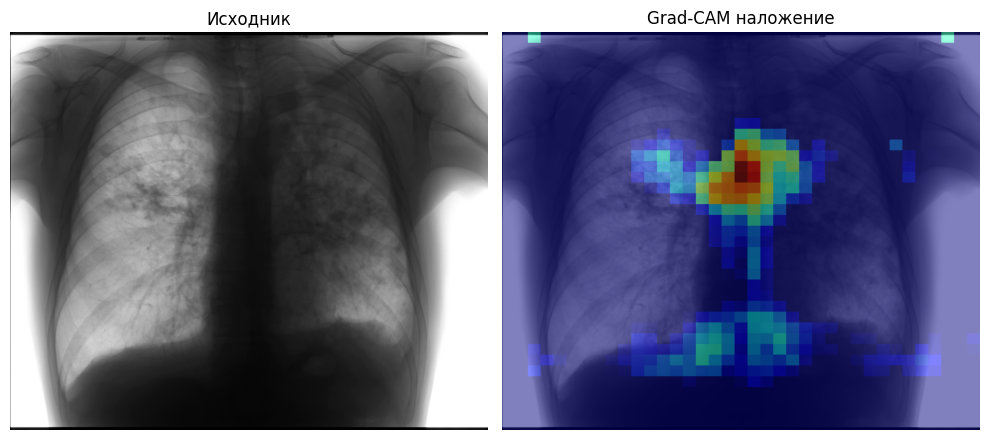

Вероятность: 0.433
Предсказанный класс: 0


In [ ]:
fig, overlay, prob, target_class = gradcam_generator.generate(
    pathology=needed_labels[0],
    image_dict=image_dict,
    test_set='test_old',
)
plt.show()
print(f"Вероятность: {prob:.3f}")

print(f"Предсказанный класс: {target_class}")

#
3*2Конец

In [ ]:
import sys

sys.exit()

In [ ]:
a = test_set_old.set_index('final_file_path')
b = test_set_new.set_index('final_file_path')
a = a[a.index.isin(b.index)].sort_index()
b = b[b.index.isin(a.index)].sort_index()
assert (a == b)['relative_file_path'].all()
(a[labels] == b[labels]).mean().round(2)

In [ ]:
# with open('outputs.pk', 'wb') as fp:
#     pickle.dump({'df': df_valid, 'ix': indices, 'proba': predictions}, fp)

# Отобрать ошибочные снимки

In [ ]:
# TODO: По суммарной доли площади патологии. Качество по задаче или папке, чтобы сравнить источники.

In [ ]:
df_valid = outputs['df']
indices = outputs['ix']
predictions = outputs['proba']

In [ ]:
import shutil

for label in predictions:
    if label != 'Очаги в легких':
        continue

    selected_df = df_valid.loc[indices].copy()
    mean_proba = predictions[label].reshape(-1, 2).mean(axis=1)
    selected_df['gt'] = selected_df[f'label_{label}']
    selected_df['proba'] = mean_proba
    selected_df['gt_proba'] = np.where(selected_df['gt'] > 0, mean_proba, 1 - mean_proba)
    y = np.repeat(selected_df['gt'], 2)

    print(label)
    print(
        f'{sklearn.metrics.roc_auc_score(y[0::2], predictions[label][0::2]):.2f}',
        f'{sklearn.metrics.roc_auc_score(y[1::2], predictions[label][1::2]):.2f}',
        f'{sklearn.metrics.roc_auc_score(y[0::2], mean_proba):.2f}',
    )
    print()

    sorted_df = selected_df.sort_values('gt_proba', ascending=True)
    sorted_df = pd.concat([sorted_df[sorted_df['gt'] == 1].head(10), sorted_df[sorted_df['gt'] == 0].head(10)])

    folder = pathlib.Path('bad_images') / label.replace(' ', '_')
    # folder.mkdir(exist_ok=True, parents=True)

    description = sorted_df.reset_index()[['task', 'labels', 'file_path', 'gt', 'gt_proba']].reset_index()
    description['index'] = description.apply(lambda row: f'{row["index"]:02}.{row["file_path"].split(".")[-1]}', axis=1)
    description['gt'] = description['gt'].apply(lambda x: 'Есть' if x == 1 else 'Нет')
    description['gt_proba'] = description['gt_proba'].apply(lambda x: round(x * 100, ndigits=1))
    description = description.rename(columns={'index': 'Имя файла', 'task': 'Номер задачи в CVAT', 'labels': 'Синдромы в разметке', 'file_path': 'Путь к файлу в CVAT', 'gt': 'Патология', 'gt_proba': 'Согласие модели с разметкой'})
    description['Результат проверки'] = ''
    description['Качество снимка'] = ''
    description['Сложность задачи'] = ''
    description['Комментарий'] = ''
    description = description[['Имя файла', 'Патология', 'Результат проверки', 'Качество снимка', 'Сложность задачи', 'Комментарий', 'Согласие модели с разметкой', 'Синдромы в разметке', 'Номер задачи в CVAT', 'Путь к файлу в CVAT']]
    # for _, row in description.iterrows():
    #     shutil.copy(row['Путь к файлу в CVAT'], folder / row['Имя файла'])

    # description.to_excel(folder / 'описание.xlsx', index=False)
    # break

In [ ]:
description

In [ ]:
selected_df[selected_df['name'].str.contains('tb715')]

In [ ]:
mean_proba == proba

# Вывод разметки

In [ ]:
import pathlib
import pandas as pd

root_dir = pathlib.Path('./bad_images')
for lbl in sorted(outputs['proba'].keys()):
    df_ = pd.read_excel(str(root_dir / lbl.replace(' ', '_') / 'описание.xlsx'))
    for _, row in df_.iterrows():
        img_fname = row['Имя файла']
        cvat_fname = row['Путь к файлу в CVAT']
        out_path = str(root_dir / lbl.replace(' ', '_') / f'{img_fname.split(".")[0]}_annot.png')
        print(out_path)
        tmp = draw_cvat_overlay_by_paths(
            image_path_on_disk=cvat_fname,
            image_name_in_xml=str(pathlib.Path(cvat_fname).relative_to('/home/y.pchelintsev/fast_storage/datasets/chest-x-ray/tb-detection')),
            xml_path='/home/y.pchelintsev/fast_storage/datasets/chest-x-ray/tb-detection/annotations.xml',
            out_path=out_path,
            # out_path=None,
            linewidth=0.5,
            legend=True,
        )
    #     break
    # break

In [ ]:
plt.imshow(tmp)

In [ ]:
import xml.etree.ElementTree as ET
from pathlib import Path
import numpy as np
import imageio
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from skimage import img_as_ubyte

def _hex_to_rgba(hexstr, alpha=1.0):
    hexstr = hexstr.lstrip('#')
    r = int(hexstr[0:2], 16)/255.0
    g = int(hexstr[2:4], 16)/255.0
    b = int(hexstr[4:6], 16)/255.0
    return (r, g, b, alpha)

def draw_cvat_overlay_by_paths(image_path_on_disk: str,
                               image_name_in_xml: str,
                               xml_path: str,
                               out_path: str = None,
                               alpha: float = 0.4,
                               linewidth: float = 1.0,
                               dpi: int = 100,
                               legend: bool = False):
    """
    Draw CVAT polygons on image.
    If legend=True -> draw legend with unique labels and colors.
    If legend=False -> place non-overlapping labels connected to polygons by thin lines.
    Returns RGB uint8 array or saves to out_path.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # label -> color
    label_color = {}
    meta = root.find('meta')
    if meta is not None:
        project = meta.find('project')
        if project is not None:
            labels = project.find('labels')
            if labels is not None:
                for lab in labels.findall('label'):
                    name_el = lab.find('name')
                    color_el = lab.find('color')
                    if name_el is not None and color_el is not None:
                        label_color[name_el.text] = color_el.text.strip()

    # find image element
    img_elem = None
    for im in root.findall('image'):
        if im.get('name') == image_name_in_xml:
            img_elem = im
            break
    if img_elem is None:
        raise ValueError(f"Image '{image_name_in_xml}' not found in XML '{xml_path}'")

    img_file = Path(image_path_on_disk)
    if not img_file.exists():
        raise FileNotFoundError(f"Image file not found: '{image_path_on_disk}'")
    img = imageio.imread(str(img_file))
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)
    elif img.shape[2] == 4:
        img = img[..., :3]

    # collect polygons and centroids
    polys = []
    for poly_el in img_elem.findall('polygon'):
        label = poly_el.get('label')
        pts_str = poly_el.get('points')
        if not pts_str:
            continue
        pts = []
        for pair in pts_str.split(';'):
            if not pair:
                continue
            x_str, y_str = pair.split(',')
            pts.append([float(x_str), float(y_str)])
        if pts:
            pts_arr = np.array(pts)
            cx = pts_arr[:,0].mean()
            cy = pts_arr[:,1].mean()
            polys.append({'label': label, 'pts': pts_arr, 'centroid': np.array([cx, cy])})

    h, w = img.shape[:2]

    fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.imshow(img)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(0, w); ax.set_ylim(h, 0)
    fig.patch.set_alpha(0.0)

    # draw polygons
    for p in polys:
        label = p['label']
        pts = p['pts']
        hexcol = label_color.get(label)
        if hexcol is None:
            hexcol = "#{:06x}".format(abs(hash(label)) % (256**3))
        rgba = _hex_to_rgba(hexcol, alpha=alpha)
        poly = Polygon(pts, closed=True, facecolor=rgba, edgecolor='black', linewidth=linewidth)
        ax.add_patch(poly)

    if legend:
        # unique labels preserving order
        seen = {}
        handles = []
        labels = []
        for p in polys:
            if p['label'] in seen:
                continue
            seen[p['label']] = True
            hexcol = label_color.get(p['label']) or "#{:06x}".format(abs(hash(p['label'])) % (256**3))
            rgba = _hex_to_rgba(hexcol, alpha=1.0)
            # create invisible patch for legend
            patch = plt.Line2D([0],[0], marker='s', markersize=10, linestyle='',
                               markerfacecolor=rgba, markeredgecolor='black')
            handles.append(patch)
            labels.append(p['label'])
        # place legend outside image on the right
        ax.legend(handles, labels, framealpha=0.8, fontsize=min(img.shape[:2]) * 1e-2, loc='lower center')#, bbox_to_anchor=(0.5, 0))
        # plt.show()
    else:
        # place non-overlapping labels connected by thin lines
        # simple greedy algorithm: for each polygon, propose a label position offset from centroid,
        # then if it collides with existing labels, push it outward along the vector.
        placed = []
        label_boxes = []  # list of (x0,y0,x1,y1)
        for p in polys:
            cx, cy = p['centroid']
            # initial offset: choose direction away from image center
            img_center = np.array([w/2, h/2])
            dir_vec = np.array([cx, cy]) - img_center
            if np.allclose(dir_vec, 0):
                dir_vec = np.array([1.0, 0.0])
            dir_norm = dir_vec / (np.linalg.norm(dir_vec) + 1e-8)
            # base distance in pixels
            base_dist = max(20, min(w,h)*0.05)
            pos = np.array([cx, cy]) + dir_norm * base_dist
            # compute text bbox approx (width ~ len*7 px, height ~12 px) — coarse but works
            text = p['label']
            tw = max(40, len(text)*7)
            th = 14
            # try to move if intersects existing boxes or outside image
            tries = 0
            while tries < 20:
                x0 = pos[0] - tw/2
                y0 = pos[1] - th/2
                x1 = x0 + tw
                y1 = y0 + th
                # clamp inside image with margin
                margin = 2
                if x0 < margin:
                    pos[0] += (margin - x0)
                if x1 > w - margin:
                    pos[0] -= (x1 - (w - margin))
                if y0 < margin:
                    pos[1] += (margin - y0)
                if y1 > h - margin:
                    pos[1] -= (y1 - (h - margin))
                # check intersection
                intersects = False
                for bx in label_boxes:
                    if not (x1 < bx[0] or x0 > bx[2] or y1 < bx[1] or y0 > bx[3]):
                        intersects = True
                        break
                if not intersects:
                    break
                # push further along dir_norm
                pos = pos + dir_norm * (base_dist * 0.5 + tries*5)
                tries += 1
            # store box
            x0 = pos[0] - tw/2; y0 = pos[1] - th/2; x1 = x0 + tw; y1 = y0 + th
            label_boxes.append((x0,y0,x1,y1))
            placed.append({'pos': pos, 'text': text, 'centroid': p['centroid'], 'color': label_color.get(p['label'])})

        # draw connectors and texts
        for it in placed:
            pos = it['pos']; text = it['text']; cent = it['centroid']; color = it['color']
            hexcol = color or "#{:06x}".format(abs(hash(text)) % (256**3))
            # line from centroid to label box edge (straight)
            ax.plot([cent[0], pos[0]], [cent[1], pos[1]], color='white', linewidth=0.8, zorder=10)
            ax.plot([cent[0], pos[0]], [cent[1], pos[1]], color='black', linewidth=0.3, zorder=11)  # thin outline
            # draw text with white text and thin black stroke for readability
            txt = ax.text(pos[0], pos[1], text, color='white', fontsize=10, weight='bold',
                          ha='center', va='center', zorder=12)
            # crude text bbox background
            rect = plt.Rectangle((pos[0]-tw/2, pos[1]-th/2), tw, th, color=_hex_to_rgba(hexcol, alpha=0.6), zorder=9)
            ax.add_patch(rect)
            # place text on top
            ax.text(pos[0], pos[1], text, color='white', fontsize=10, weight='bold',
                    ha='center', va='center', zorder=12)

    # render
    canvas = fig.canvas
    try:
        buf, _ = canvas.print_to_buffer()
        arr = np.frombuffer(buf, dtype=np.uint8)
        w_canvas, h_canvas = canvas.get_width_height()
        arr = arr.reshape((h_canvas, w_canvas, 4))
        out_img = arr[..., :3]
    except Exception:
        renderer = fig.canvas.get_renderer()
        try:
            buf = renderer.tostring_rgb()
            w_canvas, h_canvas = fig.canvas.get_width_height()
            out_img = np.frombuffer(buf, dtype=np.uint8).reshape((h_canvas, w_canvas, 3))
        except Exception:
            import tempfile
            tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
            try:
                canvas.print_png(tmp.name)
                tmp.close()
                out_img = imageio.imread(tmp.name)
                if out_img.shape[2] == 4:
                    out_img = out_img[..., :3]
            finally:
                try:
                    Path(tmp.name).unlink()
                except Exception:
                    pass

    plt.close(fig)
    out_img = img_as_ubyte(out_img)

    if out_path:
        imageio.imwrite(out_path, out_img)
    else:
        return out_img


In [ ]:
import pickle
import sklearn.metrics
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
with open('outputs.pk', 'rb') as fp:
    outputs = pickle.load(fp)

In [ ]:
labels = []
for label in outputs['proba']:
    y_true = outputs['df'][f'label_{label}']
    y_proba = outputs['proba'][label].reshape(-1, 2).mean(axis=1)
    fpr, tpr, thr = sklearn.metrics.roc_curve(y_true, y_proba)
    sens = tpr
    spec = 1 - fpr
    ix = np.argmin(np.abs(sens - spec))
    labels.append((label, sklearn.metrics.roc_auc_score(y_true, y_proba), sens[ix], spec[ix]))

labels = sorted(labels, key=lambda x: -x[1])

side = 6
maxlen = 30
fig = plt.figure(figsize=(side, side))
for label, _, sens, spec in labels:
    y_true = outputs['df'][f'label_{label}']
    y_proba = outputs['proba'][label].reshape(-1, 2).mean(axis=1)
    sklearn.metrics.RocCurveDisplay.from_predictions(y_true, y_proba, name=label[:maxlen].strip() + ('...' if len(label) > maxlen else '') + ' ' * 3, ax=fig.gca())
    print(f'{label};{sens:0.2f};{spec:0.2f}')

plt.title('ROC-кривые для 7 типов патологий (август 2025)')
plt.grid()
plt.gca().set_aspect('equal')
plt.ylabel('Чувствительность')
plt.xlabel('Специфичность')
arange = np.arange(0, 1.01, 0.1)
plt.xticks(arange, [f'{x:0.1f}' for x in arange[::-1]])
plt.yticks(arange)
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))
# plt.plot([0.0, 1.0], [0.81, 0.81], linestyle='--', color='tab:orange')
# plt.plot([1 - 0.81, 1 - 0.81], [0.0, 1.0], linestyle='--', color='tab:orange')
plt.tight_layout()

In [ ]:
def youdens_j_score(y_true, y_scores):
    # Получаем FPR, TPR и пороги
    fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_true, y_scores)

    # Вычисляем Youden’s J = TPR + (1 – FPR) – 1 = TPR – FPR
    j_scores = tpr - fpr

    # Находим максимальное значение J и соответствующий порог
    idx = j_scores.argmax()
    best_threshold = thresholds[idx]
    best_j = j_scores[idx]

    return best_j, best_threshold, fpr, tpr, thresholds

In [ ]:
inverter = albumentations.InvertImg(0)

In [ ]:
# df_valid = df_valid.sample(n=100)

In [ ]:
X_trains = {}
X_tests = {}
y_trains = {}
y_tests = {}
models = {}

for lbl, lbl_col in zip(label_list, label_cols):
    X = df_valid['file_path'].values
    y = df_valid[lbl_col].values
    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

    res = []
    for img_fname in tqdm.auto.tqdm(X_train, leave=False, smoothing=0.0):
        for img in [(img_ := read_image(img_fname)), inverter(image=img_)['image']]:
            if DO_CLAHE:
                img = skimage.exposure.equalize_adapthist(img, kernel_size=min(img.shape) // CLAHE_K)
            img = (img * 255).astype(np.uint8)
            img = PIL.Image.fromarray(img)
            res.append(pipe(img)[0])
    X_train = np.array(res)
    y_train = np.repeat(y_train, 2)
    X_trains[lbl] = X_train
    y_trains[lbl] = y_train

    res = []
    for img_fname in tqdm.auto.tqdm(X_test, leave=False, smoothing=0.0):
        for img in [(img_ := read_image(img_fname))]:
            if DO_CLAHE:
                img = skimage.exposure.equalize_adapthist(img, kernel_size=min(img.shape) // CLAHE_K)
            img = (img * 255).astype(np.uint8)
            img = PIL.Image.fromarray(img)
            res.append(pipe(img)[0])
    X_test = np.array(res)
    X_tests[lbl] = X_test
    y_tests[lbl] = y_test

    model = sklearn.model_selection.RandomizedSearchCV(
        sklearn.ensemble.GradientBoostingClassifier(random_state=0),
        {'learning_rate': scipy.stats.loguniform(2**-10, 2**-1)},
        n_iter=100,
        scoring='roc_auc',
        n_jobs=-1,
        cv=5,
        random_state=0
    )
    _ = model.fit(X_train, y_train)
    models[lbl] = model

    y_scores = model.predict_proba(X_test)[:, 1]
    best_j, best_threshold, fpr, tpr, thresholds = youdens_j_score(y_test, y_scores)
    y_pred = (y_scores >= best_threshold).astype(int)
    tn, fp, fn, tp = sklearn.metrics .confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    plot = sklearn.metrics.RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(lbl + '\n' + f'(Чувс: {sensitivity.round(2)}; Спец: {specificity.round(2)})')
    plt.grid()
    plt.xlabel('1 - Специфичность')
    plt.ylabel('Чувствительность')
    plt.tight_layout()
    plt.show()

In [ ]:
outputs['df']

In [ ]:
for label in outputs['proba']:
    # if label != 'Очаги в легких':
    #     continue
    ix = outputs['df'].reset_index()['name'].str.contains('tb715')
    proba = outputs['proba'][label].reshape(-1, 2).mean(axis=1)
    print(label, proba[ix].round(3))

In [ ]:
df = outputs['df']
ix = outputs['ix']

In [ ]:
len(df), len(ix)

In [ ]:
for lbl in labels:
    mask = df_valid[f'label_{lbl}']
    print(lbl.replace(' ', '_'), mask.sum(), mask.mean().round(2))

In [ ]:
list(outputs.keys())

In [ ]:
len(outputs['df'])

In [ ]:
len(outputs['proba'])

In [ ]:
len(outputs['proba']['Затенение (плевральный выпот)']) / 2

In [ ]:
df_valid = outputs['df']
indices = outputs['ix']
predictions = outputs['proba']

In [ ]:
selected_df = df_valid.loc[indices].copy()
for label in predictions:
    mean_proba = predictions[label].reshape(-1, 2).mean(axis=1)
    selected_df[f'proba_{label}'] = mean_proba

In [ ]:
selected_df.to_excel('outputs.xlsx', index=False)

In [ ]:
selected_df.sum()

In [ ]:
d_0 = selected_df.sample(n=200, random_state=0)
d_0.sum()

In [ ]:
sklearn.metrics.RocCurveDisplay.from_predictions(
    y_true=selected_df['label_Просветление (газ плевральной полости, в том числе пневмоторакс)'],
    y_score=selected_df['proba_Просветление (газ плевральной полости, в том числе пневмоторакс)'],
)

In [ ]:
sklearn.metrics.RocCurveDisplay.from_predictions(
    y_true=d_0['label_Просветление (газ плевральной полости, в том числе пневмоторакс)'],
    y_score=d_0['proba_Просветление (газ плевральной полости, в том числе пневмоторакс)'],
)

In [ ]:
sklearn.metrics.RocCurveDisplay.from_predictions(
    y_true=d_4['label_Просветление (газ плевральной полости, в том числе пневмоторакс)'],
    y_score=d_4['proba_Просветление (газ плевральной полости, в том числе пневмоторакс)'],
)

In [ ]:
tgt = 'label_Просветление (газ плевральной полости, в том числе пневмоторакс)'
mask = selected_df[tgt] > 0
d_1 = selected_df[mask].sample(n=50, random_state=1)
d_1.sum()

In [ ]:
tgt = 'label_Кальцинированные очаги (петрификаты)'
mask = ~selected_df.index.isin(d_1.index) & (selected_df[tgt] > 0)
d_2 = pd.concat([d_1, selected_df[mask].sample(n=50 - d_1[tgt].sum(), random_state=2)])
d_2.sum()

In [ ]:
tgt = 'label_Просветление (кольцевидная тень в легком)'
mask = ~selected_df.index.isin(d_2.index) & (selected_df[tgt] > 0)
d_3 = pd.concat([d_2, selected_df[mask].sample(n=50 - d_2[tgt].sum(), random_state=3)])
d_3.sum()

In [ ]:
tgt = 'label_Очаговая диссеминация'
mask = ~selected_df.index.isin(d_3.index) & (selected_df[tgt] > 0)
d_4 = pd.concat([d_3, selected_df[mask].sample(n=50 - d_3[tgt].sum(), random_state=4)])
d_4.sum()

In [ ]:
mask = ~selected_df.index.isin(d_4.index)
mask &= selected_df['label_Просветление (газ плевральной полости, в том числе пневмоторакс)'] == 0
d_5 = pd.concat([d_4, selected_df[mask].sample(n=300, random_state=5)])
d_5.sum()

In [ ]:
d_5['file_path'].apply(lambda x: pathlib.Path(x)).iloc[0]

In [ ]:
d_5['file_path'].apply(lambda x: pathlib.Path('/home/y.pchelintsev/fast_storage/datasets/chest-x-ray/tb-detection') in pathlib.Path(x).parents).all()

In [ ]:
d_5['file_path'].apply(lambda x: pathlib.Path('') in pathlib.Path(x).parents).all()

In [ ]:
import tqdm

In [ ]:
root = pathlib.Path('/home/y.pchelintsev/fast_storage/datasets/chest-x-ray/tb-detection')
for source_file in tqdm.tqdm(d_5['file_path']):
    source_file = pathlib.Path(source_file)
    destination_file = root / 'for_nmic_reannotation' / source_file.relative_to(root)
    destination_file.parent.mkdir(exist_ok=True, parents=True)
    shutil.copy(source_file, destination_file)

In [ ]:
len(d_4), len(d_5)

In [ ]:
import seaborn as sns

In [ ]:
sns.heatmap(selected_df[[x for x in selected_df.columns if x.startswith('label_')]].corr(), vmin=-1, vmax=1, cmap='bwr')

In [ ]:
print(selected_df[[x for x in selected_df.columns if x.startswith('label_')][:-1]].corr())

In [ ]:
sns.heatmap(d_0[[x for x in selected_df.columns if x.startswith('label_')]].corr(), vmin=-1, vmax=1, cmap='bwr')

In [ ]:
sns.heatmap(d_4[[x for x in selected_df.columns if x.startswith('label_')]].corr(), vmin=-1, vmax=1, cmap='bwr')

In [ ]:
selected_df[[x for x in selected_df.columns if x.startswith('label_')]].mean()

In [ ]:
d_0[[x for x in selected_df.columns if x.startswith('label_')]].mean()

In [ ]:
d_4[[x for x in selected_df.columns if x.startswith('label_')]].mean()